In [1]:
from google.colab import files
uploaded = files.upload()

Saving placement_predict_50k (1).csv to placement_predict_50k (1) (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")

In [5]:
CSV_PATH = "placement_predict_50k (1) (1).csv"

df = pd.read_csv(CSV_PATH)

In [7]:
import pandas as pd
# 1. Display first 5 rows
print("FIRST 5 ROWS")
print(df.head())
# 2. Display dataset shape
print("\nDATASET SHAPE")
print(df.shape)
# 3. Display column names
print("\nCOLUMN NAMES")
print(df.columns)
# 4. Display data types
print("\nDATA TYPES")
print(df.dtypes)
# 5. Display basic information
print("\nDATASET INFORMATION")
df.info()
# 6. Display statistical summary
print("\nSTATISTICAL SUMMARY")
print(df.describe())
# 7. Check missing values
print("\nMISSING VALUES")
print(df.isnull().sum())
# 8. Check duplicate rows
print("\nDUPLICATE ROWS")
print(df.duplicated().sum())
# 9. Placement status distribution
print("\nPLACEMENT STATUS DISTRIBUTION")
print(df["PlacementStatus"].value_counts())
# 10. Placement status percentage
print("\nPLACEMENT STATUS PERCENTAGE")
print(df["PlacementStatus"].value_counts(normalize=True) * 100)

FIRST 5 ROWS
   StudentID  Gender       City CollegeTier      Stream Specialisation Hostel  \
0          1  Female      Delhi       Tier3          IT    DataScience    Yes   
1          2    Male    Chennai       Tier2         ECE             AI    Yes   
2          3  Female  Hyderabad       Tier3         ECE     Networking     No   
3          4  Female     Jaipur       Tier3         ECE       Embedded     No   
4          5    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Certifications  Publications  \
0               Yes       6.39       6.84  ...               1             0   
1                No       5.95       6.74  ...               2             0   
2                No       7.13       8.11  ...               2             1   
3                No       9.37       9.97  ...               6             2   
4                No       8.25       8.99  ...               4             2   

   AptitudeTestScor

In [8]:
from google.colab import files
uploaded = files.upload()

Saving placement_predict_50k (1).csv to placement_predict_50k (1) (2).csv


In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")   # optional: gives cleaner-looking charts

num_cols = [
    'CGPA',
    'AttendancePercent',
    'AptitudeTestScore',
    'CodingTestScore',
    'SoftSkillsRating',
    'MockInterviewScore'
]


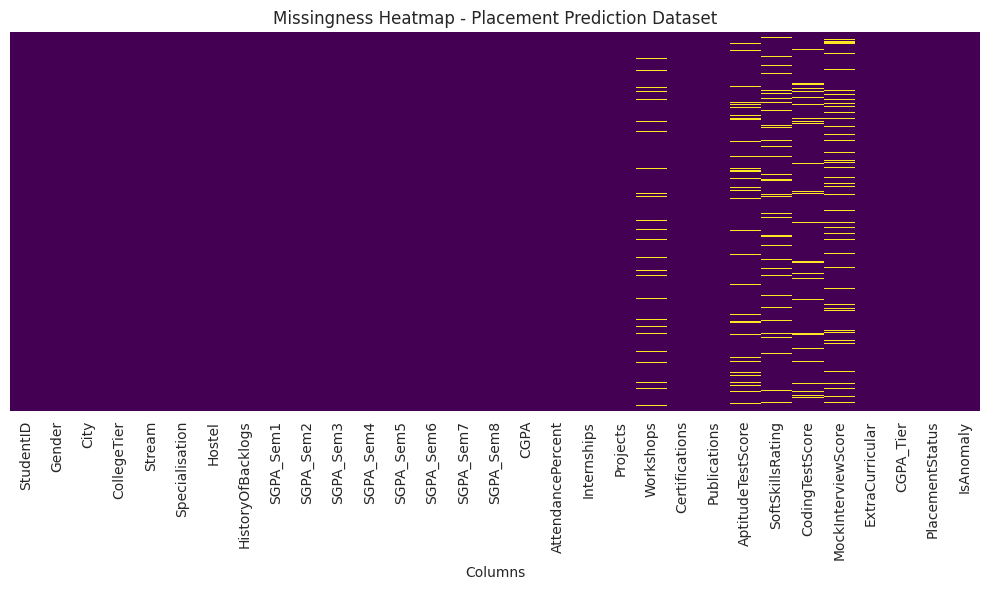

In [13]:
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

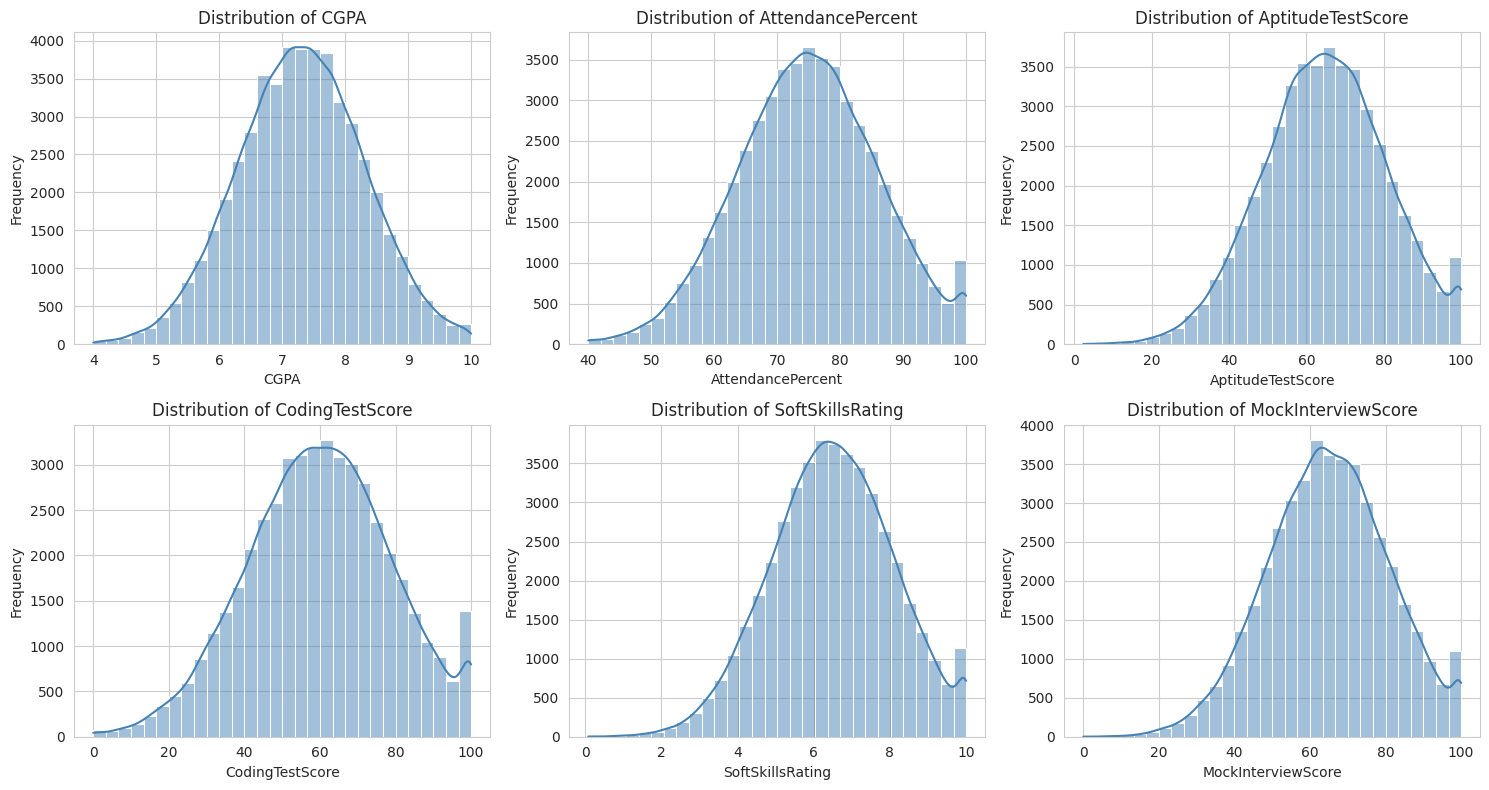

In [14]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[row, colpos],
        color='steelblue'
    )

    axes[row, colpos].set_title(f'Distribution of {col}')
    axes[row, colpos].set_xlabel(col)
    axes[row, colpos].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [16]:
pdf = PdfPages('EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Six Histograms

files.download('EDA_Report.pdf')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

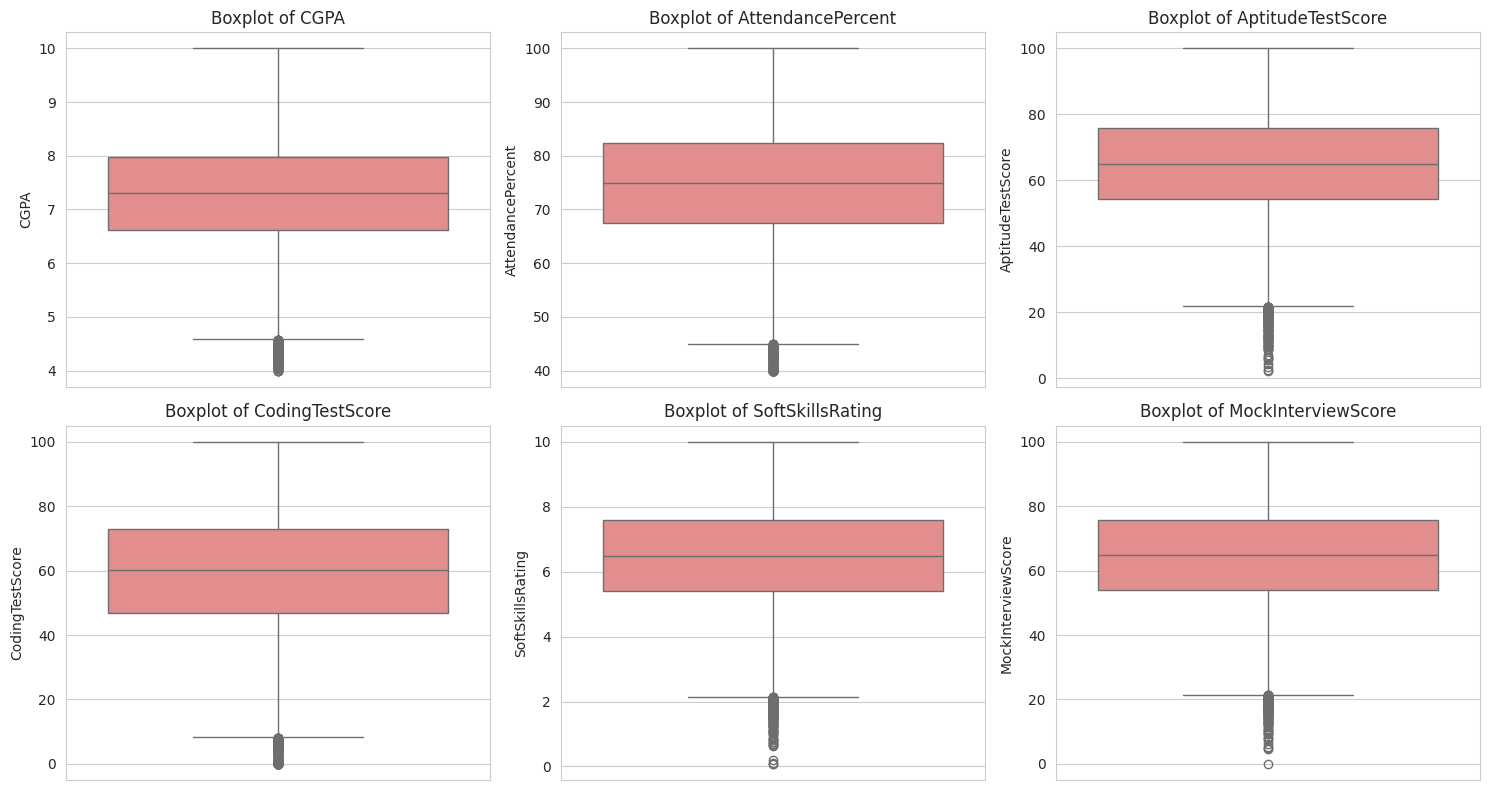

In [18]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [20]:
pdf.savefig(fig5)

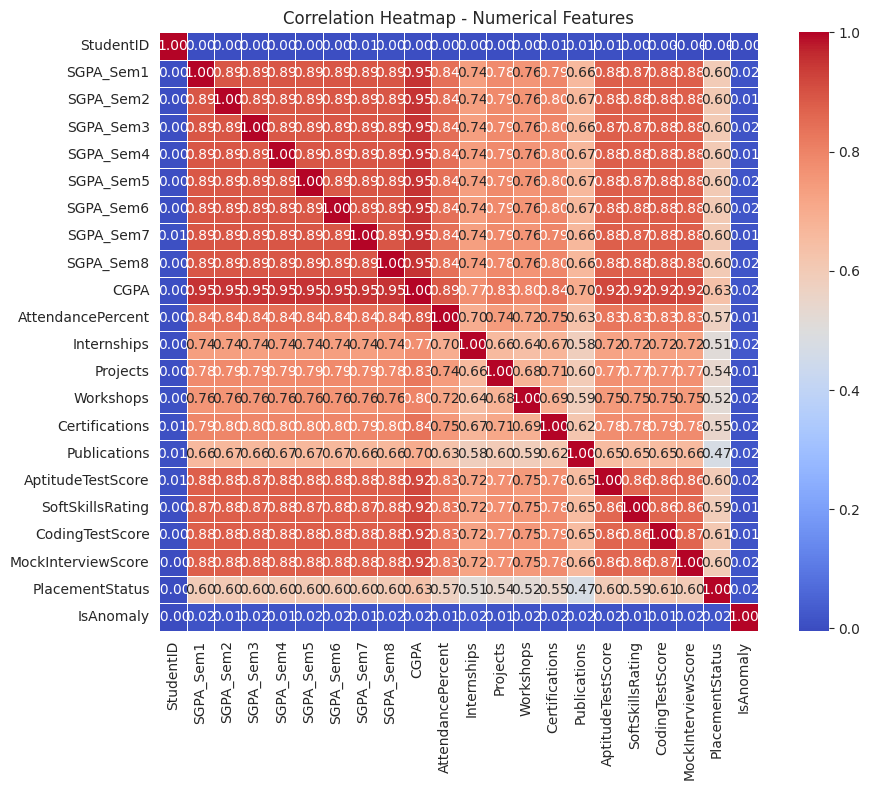

In [21]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()